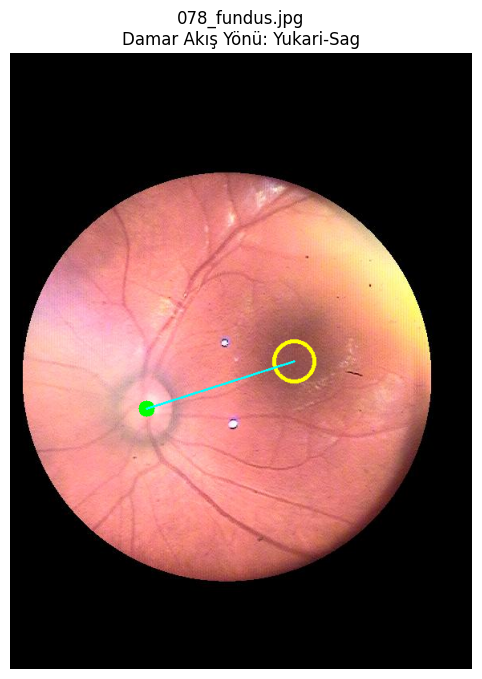

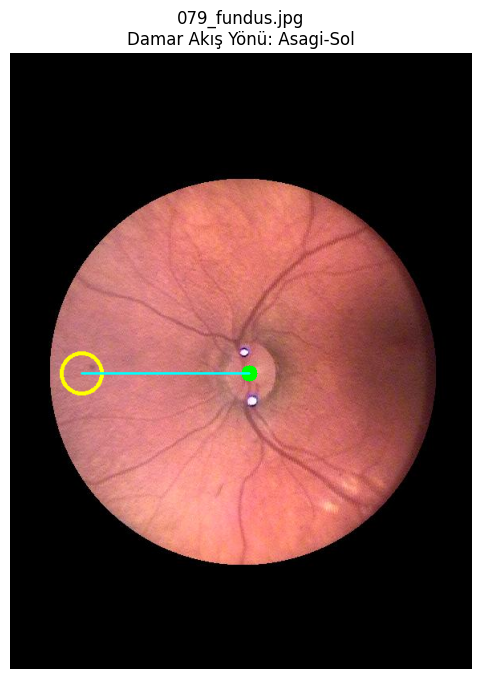

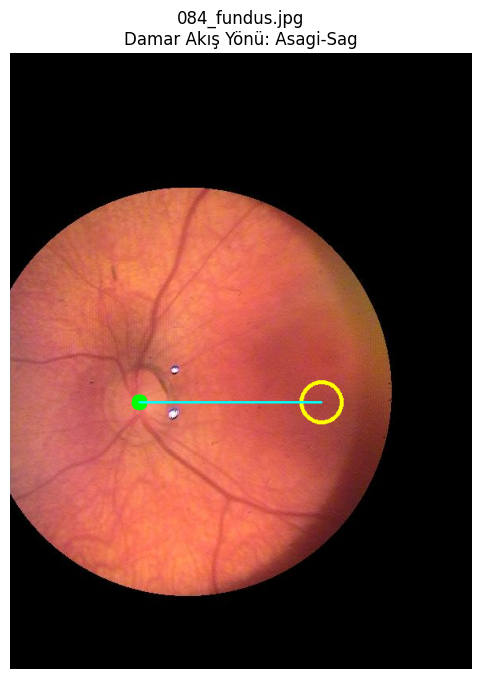

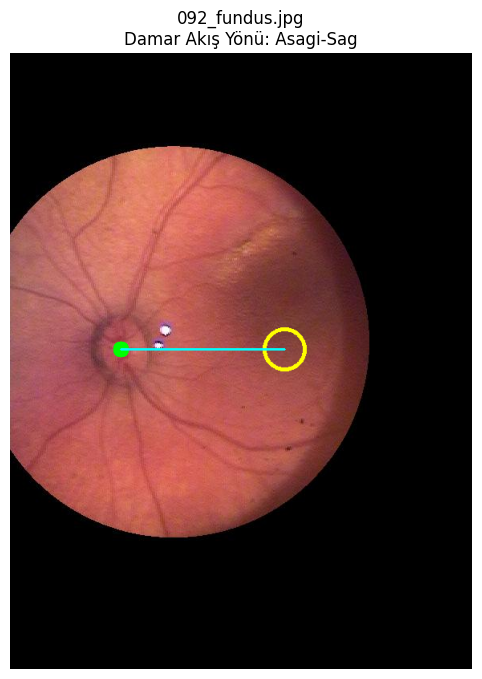

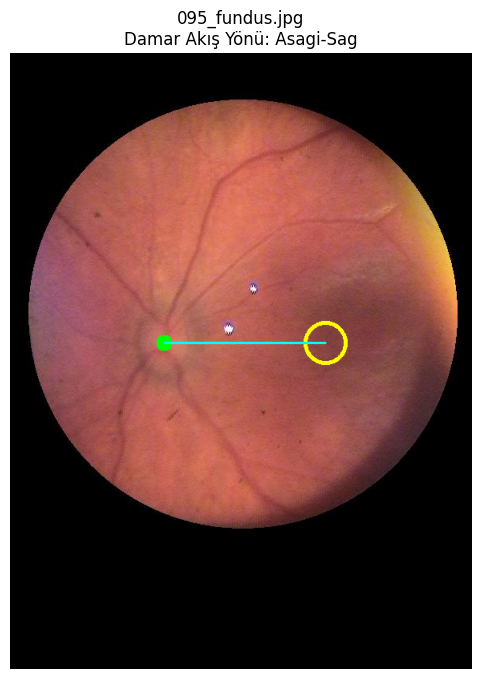

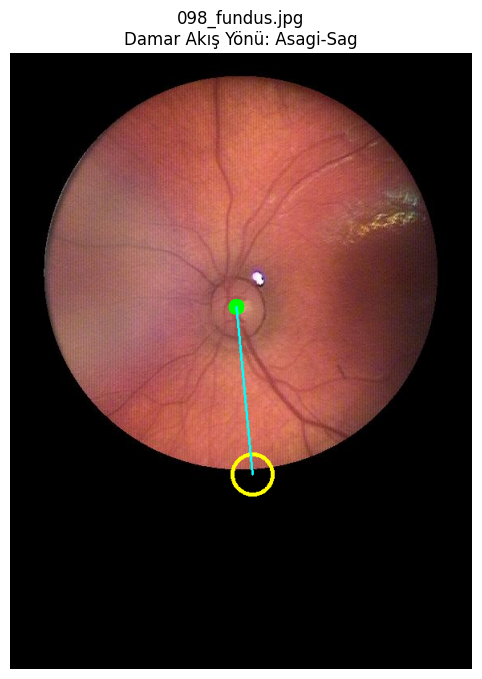

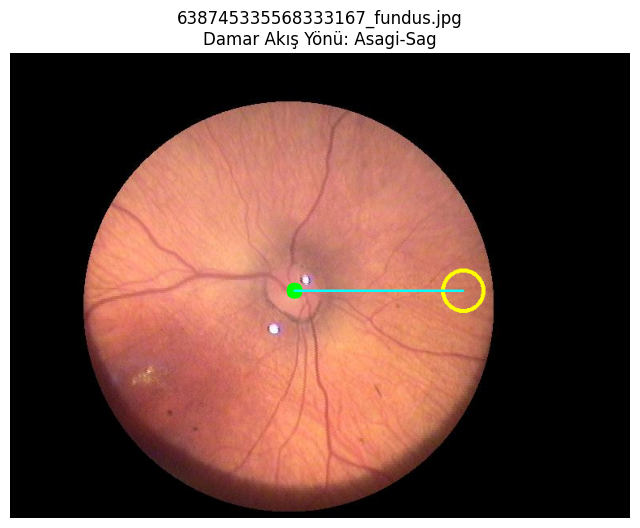

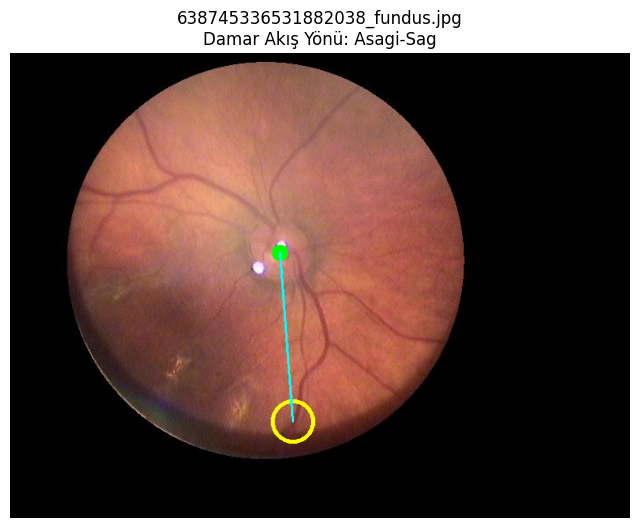

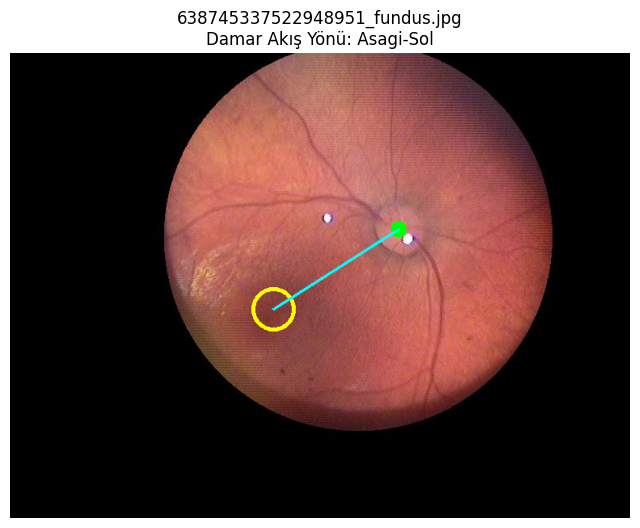

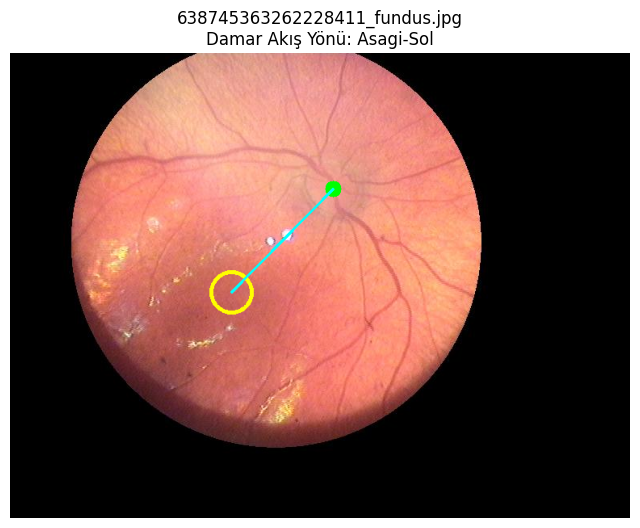

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from od_mimari import get_segmentation_model 

# --- 1. AYARLAR ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
INFANT_DATA_PATH = r"C:\Users\Dogan\Desktop\Final-Process\vessel_segment_bebek_data"
OD_MODEL_PATH = "best_od.pth"

# --- 2. ANA İŞLEME FONKSİYONU (V8) ---
def process_fundus_v8_final(image_rgb, od_model, transform, device):
    h, w = image_rgb.shape[:2]
    
    # A. OD Segmentasyonu
    input_tensor = transform(image=image_rgb)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        od_mask = (od_model(input_tensor) > 0.5).cpu().numpy().squeeze()
    od_mask_res = cv2.resize(od_mask.astype(np.uint8), (w, h))
    
    cnts, _ = cv2.findContours(od_mask_res, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
    best_od_cnt = max(cnts, key=cv2.contourArea)
    M = cv2.moments(best_od_cnt)
    if M["m00"] == 0: return None
    cx_od, cy_od = (int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"]))
    od_radius = int(np.sqrt(cv2.contourArea(best_od_cnt) / np.pi))

    # B. FOV Maskesi (Resmin kenarlarından %20 uzak dur)
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    _, f_mask = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)
    f_cnts, _ = cv2.findContours(f_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not f_cnts: return None
    fov_clean = np.zeros_like(f_mask)
    cv2.drawContours(fov_clean, [max(f_cnts, key=cv2.contourArea)], -1, 255, -1)
    fov_clean = cv2.erode(fov_clean, np.ones((81, 81), np.uint8)) # Güvenli alan için ciddi aşındırma

    # C. Laterality (Sağ-Sol) Kararı
    # Eğer OD resmin sol yarısındaysa -> Makula SAĞDADIR (Sağ Göz)
    # Eğer OD resmin sağ yarısındaysa -> Makula SOLDADIR (Sol Göz)
    is_macula_on_right = cx_od < (w // 2)

    # D. Arama Alanı Geometrisi (Wedge + Distance)
    y, x = np.indices((h, w))
    dist = np.sqrt((x - cx_od)**2 + (y - cy_od)**2)
    # Mesafe kısıtı
    dist_mask = (dist > od_radius * 2.5) & (dist < od_radius * 5.0)
    
    # Açısal kısıt (Yatayda sadece +- 30 derecelik bir dilim)
    angle = np.abs(np.rad2deg(np.arctan2(y - cy_od, x - cx_od)))
    if is_macula_on_right:
        # Sağda ararken açı 0'a yakın olmalı
        angle_mask = (angle < 30) 
    else:
        # Solda ararken açı 180'e yakın olmalı (arctan2 -180 ile 180 arasıdır)
        angle_mask = (angle > 150)

    # E. Görüntü İşleme (Yeşil Kanal)
    green_ch = image_rgb[:, :, 1]
    # Makulayı bulmak için pürüzsüzleştir ve ters çevir
    processed = cv2.GaussianBlur(green_ch, (51, 51), 0)
    inverted = cv2.bitwise_not(processed).astype(np.float32)

    # Filtreleri birleştir
    final_mask = dist_mask & angle_mask & (fov_clean > 0)
    inverted[~final_mask] = 0
    inverted[od_mask_res > 0] = 0

    # F. Nokta Atışı
    _, max_val, _, max_loc = cv2.minMaxLoc(inverted)
    if max_val == 0: return None

    return {
        "od_center": (cx_od, cy_od), 
        "macula_center": max_loc, 
        "eye_side": "Sag Goz (Makula Sagda)" if is_macula_on_right else "Sol Goz (Makula Solda)"
    }

# --- 3. MODELLER VE TEST ---
od_model = get_segmentation_model().to(DEVICE)
od_model.load_state_dict(torch.load(OD_MODEL_PATH, map_location=DEVICE))
od_model.eval()

od_trans = A.Compose([A.Resize(384, 384), A.Normalize(), ToTensorV2()])

# Görselleştirme
img_folder = os.path.join(INFANT_DATA_PATH, "val", "image")
img_names = [f for f in os.listdir(img_folder) if f.lower().endswith(('.png', '.jpg'))]

for name in img_names[:10]:
    img = cv2.cvtColor(cv2.imread(os.path.join(img_folder, name)), cv2.COLOR_BGR2RGB)
    res = process_fundus_v8_final(img, od_model, od_trans, DEVICE)
    
    if res:
        out = img.copy()
        cv2.circle(out, res["od_center"], 10, (0, 255, 0), -1)
        cv2.circle(out, res["macula_center"], 20, (255, 255, 0), 3)
        cv2.line(out, res["od_center"], res["macula_center"], (0, 255, 255), 2)
        
        plt.figure(figsize=(8, 8))
        plt.imshow(out); plt.title(f"{name}\n{res['eye_side']}"); plt.axis('off'); plt.show()